In [7]:
import NetworkToolkit as nt
import random
import collections
import matplotlib
import networkx as nx
import matplotlib.pyplot as plt
import ray
import numpy as np
import os
import re
import traceback
# import powerlaw as pl
import scipy
# import statsmodels.api as sm
# import tikzplotlib
import ast
from scipy.stats import ks_2samp, kstest, sem, t
from tqdm import tqdm
import datetime
from copy import deepcopy
import pandas as pd
top = nt.Topology.Topology()
%config Completer.use_jedi = False

In [8]:
ray.shutdown()
ray.init()

2026-01-21 20:02:28,038	INFO worker.py:2012 -- Started a local Ray instance.


Python version:,3.9.25
Ray version:,2.51.1


(raylet) [2026-01-21 20:02:58,000 E 3415785 3415785] (raylet) main.cc:975: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14
(pid=3415893) [2026-01-21 20:03:12,449 E 3415893 3416150] core_worker_process.cc:825: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14


In [ ]:
conus_graph = nt.Database.read_topology_dataset_list("Topology_Data", "topology-paper","ILP RWA assignment",
                            find_dic={"name": "CONUS"}, node_data=True)
nsfnet_graph = nt.Database.read_topology_dataset_list("Topology_Data", "real","ILP RWA assignment",
                            find_dic={"name": "NSFNET"}, node_data=True)

In [ ]:
sbag_conus_graphs = nt.Database.read_topology_dataset_list("Topology_Data", "topology-paper","ILP RWA assignment",
                            find_dic={"alpha":5, "name":"SBAG", "nodes":30})
ba_conus_graphs = nt.Database.read_topology_dataset_list("Topology_Data", "topology-paper","ILP RWA assignment",
                            find_dic={"name":"BA", "nodes":30})
er_conus_graphs = nt.Database.read_topology_dataset_list("Topology_Data", "topology-paper","ILP RWA assignment",
                            find_dic={"name":"ER", "nodes":30})
sbag_nsfnet_graphs = nt.Database.read_topology_dataset_list("Topology_Data", "topology-paper","ILP capacity RWA assignment",
                            find_dic={"alpha":5, "name":"SBAG", "nodes":14, "ILP capacity RWA assignment":{"$exists":True}})
ba_nsfnet_graphs = nt.Database.read_topology_dataset_list("Topology_Data", "topology-paper","ILP capacity RWA assignment",
                            find_dic={"name":"BA", "nodes":14, "ILP capacity RWA assignment":{"$exists":True}})
er_nsfnet_graphs = nt.Database.read_topology_dataset_list("Topology_Data", "topology-paper","ILP capacity RWA assignment",
                            find_dic={"name":"ER", "nodes":14, "ILP capacity RWA assignment":{"$exists":True}})




In [ ]:
graph_list = []
graph_list += conus_graph
graph_list += nsfnet_graph
graph_list += sbag_conus_graphs
graph_list += ba_conus_graphs
graph_list += er_conus_graphs
graph_list += sbag_nsfnet_graphs
graph_list += ba_nsfnet_graphs
graph_list += er_nsfnet_graphs

In [ ]:
throughput_df = nt.Database.read_topology_dataset_list("Topology_Data", "topology_paper_erratum", "ILP Capacity", "name", "nodes", "edges",
                                                       "ILP total_fibre_len", "ILP avg_edge_len", "ILP avg_path_len",
                                                       "ILP lightpaths", find_dic = {"nodes":{"$gte":10}}, df=True)


In [ ]:
throughput_df.to_csv("throughput_df.csv")


In [ ]:
throughput_df["ILP Capacity"]*=1e-12

In [ ]:
graph = sbag_conus_graphs[0][0]
rwa = {int(wave): [path for path in sbag_conus_graphs[0][2][wave]]for wave in sbag_conus_graphs[0][2]}

network = nt.Network.OpticalNetwork(graph, channel_bandwidth=16e9,fibre_num=1)
network.physical_layer.add_uniform_launch_power_to_links(network.channels)
network.physical_layer.add_wavelengths_to_links(rwa)
# network.physical_layer.add_LOGON_launch_power_to_links(network.channels)
network.physical_layer.add_non_linear_NSR_to_links(channel_bandwidth=16e9, channels_full=network.channels)
throughput = network.physical_layer.get_lightpath_capacities_PLI(rwa)[0]

In [ ]:
throughput*1e-12

In [ ]:
throughput*1e-12

In [ ]:
def parralel_calculate_new_throughput(graph_list):
    pb = nt.Tools.ProgressBar(len(graph_list))
    actor = pb.actor
    tasks = [calculate_new_throughput.remote(item, actor=actor) for item in graph_list]
    pb.print_until_done()
    throughput_vals = ray.get(tasks)
    return throughput_vals

def calculate_edges(graph_list):
    edge_list = []
    for graph, _id, rwa in tqdm(graph_list):
        edge_list.append(graph.number_of_edges())
    return edge_list

def calculate_lightpaths_rwa(graph_list):
    lightpaths_list = []
    for graph, _id, rwa in tqdm(graph_list):
        lightpaths_list.append(sum([1  for wave in rwa for path in rwa[wave]]))
        
    return lightpaths_list
                
def get_box_plot_data(boxplot, ind=0):
    whiskers = [item.get_ydata() for item in boxplot['whiskers']]
    _median = boxplot['medians'][0].get_ydata()[0]
    _75 = whiskers[1][0]
    _25 = whiskers[0][0]
    _top = whiskers[1][1]
    _bottom = whiskers[0][1]
    _data = np.array([ind, _median, _75, _25, _top, _bottom])
    return _data

def calculate_new_throughput_single(item, actor=None):
    try:
        graph = item[0]
        rwa = {int(wave): [path for path in item[2][wave]]for wave in item[2]}
        network = nt.Network.OpticalNetwork(graph, channel_bandwidth=16e9,fibre_num=1)
        network.physical_layer.add_uniform_launch_power_to_links(network.channels)
        # network.physical_layer.add_LOGON_launch_power_to_links(network.channels)
        network.physical_layer.add_wavelengths_to_links(rwa)
        network.physical_layer.add_non_linear_NSR_to_links(channel_bandwidth=16e9, channels_full=network.channels)
        throughput = network.physical_layer.get_lightpath_capacities_PLI(rwa)[0]
        if actor:
            actor.update.remote(1)
    except Exception as err:
        traceback.print_exc()
    return throughput

@ray.remote
def calculate_new_throughput(item, actor=None):
    try:
        graph = item[0]
        rwa = {int(wave): [path for path in item[2][wave]]for wave in item[2]}
        network = nt.Network.OpticalNetwork(graph, channel_bandwidth=16e9,fibre_num=1)
        network.physical_layer.add_uniform_launch_power_to_links(network.channels)
        # network.physical_layer.add_LOGON_launch_power_to_links(network.channels)
        network.physical_layer.add_wavelengths_to_links(rwa)
        network.physical_layer.add_non_linear_NSR_to_links(channel_bandwidth=16e9, channels_full=network.channels)
        throughput = network.physical_layer.get_lightpath_capacities_PLI(rwa)[0]
        if actor:
            actor.update.remote(1)
    except Exception as err:
        traceback.print_exc()
    return throughput

def update_networks(db, collection, graph_list):
    for graph, _id, throughput in tqdm(graph_list):
        
        nt.Database.update_data_with_id(db, collection, _id, newvals={"$set":{"ILP Capacity":float(throughput),
                                                                              "Erratum capacity bandwidth":16e9,
                                                                              "Erratum capacity channels":312,
                                                                              "Erratum capacity timestamp":datetime.datetime.utcnow(),
                                                                              
        
                    }})
        

        

In [ ]:
sbag_conus_throughput_vals = parralel_calculate_new_throughput(sbag_conus_graphs)

In [ ]:
ba_conus_throughput_vals = parralel_calculate_new_throughput(ba_conus_graphs)

In [ ]:
er_conus_throughput_vals = parralel_calculate_new_throughput(er_conus_graphs)

In [ ]:
sbag_nsfnet_throughput_vals = parralel_calculate_new_throughput(sbag_nsfnet_graphs)

In [ ]:
ba_nsfnet_throughput_vals = parralel_calculate_new_throughput(ba_nsfnet_graphs)

In [ ]:
er_nsfnet_throughput_vals = parralel_calculate_new_throughput(er_nsfnet_graphs)

In [ ]:
conus_throughput = parralel_calculate_new_throughput(conus_graph)
nsfnet_throughput = parralel_calculate_new_throughput(nsfnet_graph)

In [ ]:
len(er_nsfnet_throughput_vals)

In [ ]:
data_list = sbag_conus_throughput_vals+ba_conus_throughput_vals+er_conus_throughput_vals+sbag_nsfnet_throughput_vals+ba_nsfnet_throughput_vals+er_nsfnet_throughput_vals
graph_list = sbag_conus_graphs+ba_conus_graphs+er_conus_graphs+sbag_nsfnet_graphs+ba_nsfnet_graphs+er_nsfnet_graphs
update_list = [(graph, _id, throughput) for ((graph, _id, rwa),throughput) in tqdm(zip(graph_list, data_list))]

In [ ]:
update_networks("Topology_Data","topology_paper_erratum", update_list)

In [ ]:
update_networks("Topology_Data","topology_paper_erratum", [(conus_graph[0][0], conus_graph[0][1], conus_throughput[0])])

In [ ]:
update_networks("Topology_Data","topology_paper_erratum", [(nsfnet_graph[0][0], nsfnet_graph[0][1], nsfnet_throughput[0])])

In [ ]:
graph_list = nt.Database.read_topology_dataset_list("Topology_Data", "topology_paper_erratum","ILP Capacity RWA assignment",
                            find_dic={"nodes":{"$gte":10}})

In [ ]:
for graph, _id, rwa in tqdm(graph_list):
    lightpaths = sum([1  for wave in rwa for path in rwa[wave]])
    total_fibre_len = sum([graph[s][d]["weight"]*80 for s,d in graph.edges])
    avg_edge_len = np.mean([graph[s][d]["weight"]*80 for s,d in graph.edges])
    avg_path_len = np.mean([ sum([graph[s][d]["weight"]*80 for s,d in nt.Tools.nodes_to_edges(path)]) for wave in rwa for path in rwa[wave] ])
    nt.Database.update_data_with_id("Topology_Data", "topology_paper_erratum", _id, newvals={"$set":{"ILP lightpaths":lightpaths,
                                                                          "ILP lightpaths timestamp":datetime.datetime.utcnow(),
                                                                                                     "ILP total_fibre_len":total_fibre_len,
                                                                                                     "ILP avg_edge_len":avg_edge_len,
                                                                                                     "ILP avg_path_len":avg_path_len,
                                                                              
        
                    }})

In [ ]:
median = np.median(data)
upper_quartile = np.percentile(data, 75)
lower_quartile = np.percentile(data, 25)

iqr = upper_quartile - lower_quartile
upper_whisker = data[data<=upper_quartile+1.5*iqr].max()
lower_whisker = data[data>=lower_quartile-1.5*iqr].min()

In [ ]:
sbag_conus_boxplot = plt.boxplot(throughput_df[np.logical_and(throughput_df["name"]=="SBAG", throughput_df["nodes"]==30)]["ILP Capacity"], positions=[3], labels=["SNR-BA"], showfliers=False)
ba_conus_boxplot = plt.boxplot(throughput_df[np.logical_and(throughput_df["name"]=="BA", throughput_df["nodes"]==30)]["ILP Capacity"], positions=[2], labels=["BA"], showfliers=False)
er_conus_boxplot = plt.boxplot(throughput_df[np.logical_and(throughput_df["name"]=="ER", throughput_df["nodes"]==30)]["ILP Capacity"], positions=[1], labels=["ER"], showfliers=False)
plt.scatter(range(1,4), [705.6]*3)
plt.ylabel("Maximum Achievable Throughput [Tbps]")
plt.grid()
plt.show()
plt.scatter(range(1,4), [345.50]*3)
sbag_nsfnet_boxplot = plt.boxplot(throughput_df[np.logical_and(throughput_df["name"]=="SBAG", throughput_df["nodes"]==14)]["ILP Capacity"], positions=[3], labels=["SNR-BA"], showfliers=False)
ba_nsfnet_boxplot = plt.boxplot(throughput_df[np.logical_and(throughput_df["name"]=="BA", throughput_df["nodes"]==14)]["ILP Capacity"], positions=[2], labels=["BA"], showfliers=False)
er_nsfnet_boxplot = plt.boxplot(throughput_df[np.logical_and(throughput_df["name"]=="ER", throughput_df["nodes"]==14)]["ILP Capacity"], positions=[1], labels=["ER"], showfliers=False)
plt.ylabel("Maximum Achievable Throughput [Tbps]")
plt.grid()
plt.show()

In [ ]:
throughput_df[np.logical_and(throughput_df["name"]=="BA", throughput_df["nodes"]==30)]["ILP Capacity"].mean()/throughput_df[np.logical_and(throughput_df["name"]=="SBAG", throughput_df["nodes"]==30)]["ILP Capacity"].mean()

In [ ]:
throughput_df[np.logical_and(throughput_df["name"]=="SBAG", throughput_df["nodes"]==30)]["ILP lightpaths"].mean()/throughput_df[np.logical_and(throughput_df["name"]=="BA", throughput_df["nodes"]==30)]["ILP lightpaths"].mean()

In [ ]:
throughput_df[np.logical_and(throughput_df["name"]=="SBAG", throughput_df["nodes"]==30)]["throughput/lightpath"].mean()/throughput_df[np.logical_and(throughput_df["name"]=="BA", throughput_df["nodes"]==30)]["throughput/lightpath"].mean()


In [ ]:
throughput_df[np.logical_and(throughput_df["name"]=="ER", throughput_df["nodes"]==30)]["ILP Capacity"].mean()/throughput_df[np.logical_and(throughput_df["name"]=="SBAG", throughput_df["nodes"]==30)]["ILP Capacity"].mean()

In [ ]:
throughput_df[np.logical_and(throughput_df["name"]=="SBAG", throughput_df["nodes"]==30)]["ILP lightpaths"].mean()/throughput_df[np.logical_and(throughput_df["name"]=="ER", throughput_df["nodes"]==30)]["ILP lightpaths"].mean()

In [ ]:
throughput_df[np.logical_and(throughput_df["name"]=="SBAG", throughput_df["nodes"]==30)]["throughput/lightpath"].mean()/throughput_df[np.logical_and(throughput_df["name"]=="ER", throughput_df["nodes"]==30)]["throughput/lightpath"].mean()


In [ ]:
throughput_df[np.logical_and(throughput_df["name"]=="SBAG", throughput_df["nodes"]==14)]["ILP Capacity"].mean()/throughput_df[np.logical_and(throughput_df["name"]=="BA", throughput_df["nodes"]==14)]["ILP Capacity"].mean()

In [ ]:
throughput_df[np.logical_and(throughput_df["name"]=="SBAG", throughput_df["nodes"]==14)]["ILP lightpaths"].mean()/throughput_df[np.logical_and(throughput_df["name"]=="BA", throughput_df["nodes"]==14)]["ILP lightpaths"].mean()

In [ ]:
throughput_df[np.logical_and(throughput_df["name"]=="SBAG", throughput_df["nodes"]==14)]["ILP Capacity"].mean()/throughput_df[np.logical_and(throughput_df["name"]=="ER", throughput_df["nodes"]==14)]["ILP Capacity"].mean()

In [ ]:
throughput_df[np.logical_and(throughput_df["name"]=="SBAG", throughput_df["nodes"]==14)]["ILP lightpaths"].mean()/throughput_df[np.logical_and(throughput_df["name"]=="ER", throughput_df["nodes"]==14)]["ILP lightpaths"].mean()

In [ ]:
sbag_conus_boxplot_data = get_box_plot_data(sbag_conus_boxplot)
ba_conus_boxplot_data = get_box_plot_data(ba_conus_boxplot)
er_conus_boxplot_data = get_box_plot_data(er_conus_boxplot)

sbag_nsfnet_boxplot_data = get_box_plot_data(sbag_nsfnet_boxplot)
ba_nsfnet_boxplot_data = get_box_plot_data(ba_nsfnet_boxplot)
er_nsfnet_boxplot_data = get_box_plot_data(er_nsfnet_boxplot)

In [ ]:
np.savetxt('sbag_conus_graphs.dat', sbag_conus_boxplot_data, newline=" ", fmt="%d")
np.savetxt('ba_conus_graphs.dat', ba_conus_boxplot_data, newline=" ", fmt="%d")
np.savetxt('er_conus_graphs.dat', er_conus_boxplot_data, newline=" ", fmt="%d")

np.savetxt('sbag_nsfnet_graphs.dat', sbag_nsfnet_boxplot_data, newline=" ", fmt="%d")
np.savetxt('er_nsfnet_graphs.dat', er_nsfnet_boxplot_data, newline=" ", fmt="%d")
np.savetxt('ba_nsfnet_graphs.dat', ba_nsfnet_boxplot_data, newline=" ", fmt="%d")

In [ ]:
sbag_conus_lightpaths = calculate_lightpaths_rwa(sbag_conus_graphs)
ba_conus_lightpaths = calculate_lightpaths_rwa(ba_conus_graphs)
er_conus_lightpaths = calculate_lightpaths_rwa(er_conus_graphs)

sbag_nsfnet_lightpaths = calculate_lightpaths_rwa(sbag_nsfnet_graphs)
ba_nsfnet_lightpaths = calculate_lightpaths_rwa(ba_nsfnet_graphs)
er_nsfnet_lightpaths = calculate_lightpaths_rwa(er_nsfnet_graphs)

In [ ]:
sbag_conus_norm = [throughput/(lightpaths) for throughput,lightpaths in zip(sbag_conus_throughput_vals,sbag_conus_lightpaths)]
ba_conus_norm = [throughput/(lightpaths) for throughput,lightpaths in zip(ba_conus_throughput_vals,ba_conus_lightpaths)]
er_conus_norm = [throughput/(lightpaths) for throughput,lightpaths in zip(er_conus_throughput_vals,er_conus_lightpaths)]

sbag_nsfnet_norm = [throughput/(lightpaths) for throughput,lightpaths in zip(sbag_nsfnet_throughput_vals,sbag_conus_lightpaths)]
ba_nsfnet_norm = [throughput/(lightpaths) for throughput,lightpaths in zip(ba_nsfnet_throughput_vals,sbag_conus_lightpaths)]
er_nsfnet_norm = [throughput/(lightpaths) for throughput,lightpaths in zip(er_nsfnet_throughput_vals,sbag_conus_lightpaths)]

In [ ]:
throughput_df["throughput/lightpath"] = throughput_df["ILP Capacity"]/throughput_df["ILP lightpaths"]

In [ ]:
throughput_df["throughput/lightpath"] *= 1e3

In [ ]:
sbag_conus_boxplot_norm = plt.boxplot(throughput_df[np.logical_and(throughput_df["name"]=="SBAG", throughput_df["nodes"]==30)]["throughput/lightpath"], positions=[3], labels=["SNR-BA"], showfliers=False)
ba_conus_boxplot_norm = plt.boxplot(throughput_df[np.logical_and(throughput_df["name"]=="BA", throughput_df["nodes"]==30)]["throughput/lightpath"], positions=[2], labels=["BA"], showfliers=False)
er_conus_boxplot_norm = plt.boxplot(throughput_df[np.logical_and(throughput_df["name"]=="ER", throughput_df["nodes"]==30)]["throughput/lightpath"], positions=[1], labels=["ER"], showfliers=False)
plt.scatter(range(1,4), throughput_df[throughput_df["name"]=="CONUS"]["throughput/lightpath"].tolist()*3)
plt.ylabel("Maximum Achievable Throughput [Tbps]")
plt.grid()
plt.show()
plt.scatter(range(1,4), throughput_df[throughput_df["name"]=="NSFNET"]["throughput/lightpath"].tolist()*3)
sbag_nsfnet_boxplot_norm = plt.boxplot(throughput_df[np.logical_and(throughput_df["name"]=="SBAG", throughput_df["nodes"]==14)]["throughput/lightpath"], positions=[3], labels=["SNR-BA"], showfliers=False)
ba_nsfnet_boxplot_norm = plt.boxplot(throughput_df[np.logical_and(throughput_df["name"]=="BA", throughput_df["nodes"]==14)]["throughput/lightpath"], positions=[2], labels=["BA"], showfliers=False)
er_nsfnet_boxplot_norm = plt.boxplot(throughput_df[np.logical_and(throughput_df["name"]=="ER", throughput_df["nodes"]==14)]["throughput/lightpath"], positions=[1], labels=["ER"], showfliers=False)
plt.ylabel("Maximum Achievable Throughput [Tbps]")
plt.grid()
plt.show()

In [ ]:
print(throughput_df[throughput_df["name"]=="CONUS"]["throughput/lightpath"])
print(throughput_df[throughput_df["name"]=="NSFNET"]["throughput/lightpath"])

In [ ]:
sbag_conus_boxplot_norm_data = get_box_plot_data(sbag_conus_boxplot_norm)
ba_conus_boxplot_norm_data = get_box_plot_data(ba_conus_boxplot_norm)
er_conus_boxplot_norm_data = get_box_plot_data(er_conus_boxplot_norm)

sbag_nsfnet_boxplot_norm_data = get_box_plot_data(sbag_nsfnet_boxplot_norm)
ba_nsfnet_boxplot_norm_data = get_box_plot_data(ba_nsfnet_boxplot_norm)
er_nsfnet_boxplot_norm_data = get_box_plot_data(er_nsfnet_boxplot_norm)

In [ ]:
np.savetxt('sbag_conus_graphs_norm.dat', sbag_conus_boxplot_norm_data, newline=" ", fmt="%d")
np.savetxt('ba_conus_graphs_norm.dat', ba_conus_boxplot_norm_data, newline=" ", fmt="%d")
np.savetxt('er_conus_graphs_norm.dat', er_conus_boxplot_norm_data, newline=" ", fmt="%d")

np.savetxt('sbag_nsfnet_graphs_norm.dat', sbag_nsfnet_boxplot_norm_data, newline=" ", fmt="%d")
np.savetxt('er_nsfnet_graphs_norm.dat', er_nsfnet_boxplot_norm_data, newline=" ", fmt="%d")
np.savetxt('ba_nsfnet_graphs_norm.dat', ba_nsfnet_boxplot_norm_data, newline=" ", fmt="%d")

In [ ]:
print("--------------- CONUS -----------------")
print("T\lambda: {}".format(throughput_df[np.logical_and(throughput_df["name"]=="CONUS", throughput_df["nodes"]==30)]["throughput/lightpath"].mean()))
print("T: {}".format(throughput_df[np.logical_and(throughput_df["name"]=="CONUS", throughput_df["nodes"]==30)]["ILP Capacity"].mean()))
print("P: {}".format(throughput_df[np.logical_and(throughput_df["name"]=="CONUS", throughput_df["nodes"]==30)]["ILP avg_path_len"].mean()))
print("E: {}".format(throughput_df[np.logical_and(throughput_df["name"]=="CONUS", throughput_df["nodes"]==30)]["edges"].mean()))
print("L_f: {}".format(throughput_df[np.logical_and(throughput_df["name"]=="CONUS", throughput_df["nodes"]==30)]["ILP total_fibre_len"].mean()))
print("L_e: {}".format(throughput_df[np.logical_and(throughput_df["name"]=="CONUS", throughput_df["nodes"]==30)]["ILP avg_edge_len"].mean()))
print("--------------- CONUS SBAG -----------------")
print("T\lambda: {}".format(throughput_df[np.logical_and(throughput_df["name"]=="SBAG", throughput_df["nodes"]==30)]["throughput/lightpath"].mean()))
print("T: {}".format(throughput_df[np.logical_and(throughput_df["name"]=="SBAG", throughput_df["nodes"]==30)]["ILP Capacity"].mean()))
print("P: {}".format(throughput_df[np.logical_and(throughput_df["name"]=="SBAG", throughput_df["nodes"]==30)]["ILP avg_path_len"].mean()))
print("E: {}".format(throughput_df[np.logical_and(throughput_df["name"]=="SBAG", throughput_df["nodes"]==30)]["edges"].mean()))
print("L_f: {}".format(throughput_df[np.logical_and(throughput_df["name"]=="SBAG", throughput_df["nodes"]==30)]["ILP total_fibre_len"].mean()))
print("L_e: {}".format(throughput_df[np.logical_and(throughput_df["name"]=="SBAG", throughput_df["nodes"]==30)]["ILP avg_edge_len"].mean()))
print("--------------- CONUS BA -----------------")
print("T\lambda: {}".format(throughput_df[np.logical_and(throughput_df["name"]=="BA", throughput_df["nodes"]==30)]["throughput/lightpath"].mean()))
print("T: {}".format(throughput_df[np.logical_and(throughput_df["name"]=="BA", throughput_df["nodes"]==30)]["ILP Capacity"].mean()))
print("P: {}".format(throughput_df[np.logical_and(throughput_df["name"]=="BA", throughput_df["nodes"]==30)]["ILP avg_path_len"].mean()))
print("E: {}".format(throughput_df[np.logical_and(throughput_df["name"]=="BA", throughput_df["nodes"]==30)]["edges"].mean()))
print("L_f: {}".format(throughput_df[np.logical_and(throughput_df["name"]=="BA", throughput_df["nodes"]==30)]["ILP total_fibre_len"].mean()))
print("L_e: {}".format(throughput_df[np.logical_and(throughput_df["name"]=="BA", throughput_df["nodes"]==30)]["ILP avg_edge_len"].mean()))
print("--------------- CONUS ER -----------------")
print("T\lambda: {}".format(throughput_df[np.logical_and(throughput_df["name"]=="ER", throughput_df["nodes"]==30)]["throughput/lightpath"].mean()))
print("T: {}".format(throughput_df[np.logical_and(throughput_df["name"]=="ER", throughput_df["nodes"]==30)]["ILP Capacity"].mean()))
print("P: {}".format(throughput_df[np.logical_and(throughput_df["name"]=="ER", throughput_df["nodes"]==30)]["ILP avg_path_len"].mean()))
print("E: {}".format(throughput_df[np.logical_and(throughput_df["name"]=="ER", throughput_df["nodes"]==30)]["edges"].mean()))
print("L_f: {}".format(throughput_df[np.logical_and(throughput_df["name"]=="ER", throughput_df["nodes"]==30)]["ILP total_fibre_len"].mean()))
print("L_e: {}".format(throughput_df[np.logical_and(throughput_df["name"]=="ER", throughput_df["nodes"]==30)]["ILP avg_edge_len"].mean()))
print("--------------- NSFNET -----------------")
print("T\lambda: {}".format(throughput_df[np.logical_and(throughput_df["name"]=="NSFNET", throughput_df["nodes"]==14)]["throughput/lightpath"].mean()))
print("T: {}".format(throughput_df[np.logical_and(throughput_df["name"]=="NSFNET", throughput_df["nodes"]==14)]["ILP Capacity"].mean()))
print("P: {}".format(throughput_df[np.logical_and(throughput_df["name"]=="NSFNET", throughput_df["nodes"]==14)]["ILP avg_path_len"].mean()))
print("E: {}".format(throughput_df[np.logical_and(throughput_df["name"]=="NSFNET", throughput_df["nodes"]==14)]["edges"].mean()))
print("L_f: {}".format(throughput_df[np.logical_and(throughput_df["name"]=="NSFNET", throughput_df["nodes"]==14)]["ILP total_fibre_len"].mean()))
print("L_e: {}".format(throughput_df[np.logical_and(throughput_df["name"]=="NSFNET", throughput_df["nodes"]==14)]["ILP avg_edge_len"].mean()))
print("--------------- NSFNET SBAG -----------------")
print("T\lambda: {}".format(throughput_df[np.logical_and(throughput_df["name"]=="SBAG", throughput_df["nodes"]==14)]["throughput/lightpath"].mean()))
print("T: {}".format(throughput_df[np.logical_and(throughput_df["name"]=="SBAG", throughput_df["nodes"]==14)]["ILP Capacity"].mean()))
print("P: {}".format(throughput_df[np.logical_and(throughput_df["name"]=="SBAG", throughput_df["nodes"]==14)]["ILP avg_path_len"].mean()))
print("E: {}".format(throughput_df[np.logical_and(throughput_df["name"]=="SBAG", throughput_df["nodes"]==14)]["edges"].mean()))
print("L_f: {}".format(throughput_df[np.logical_and(throughput_df["name"]=="SBAG", throughput_df["nodes"]==14)]["ILP total_fibre_len"].mean()))
print("L_e: {}".format(throughput_df[np.logical_and(throughput_df["name"]=="SBAG", throughput_df["nodes"]==14)]["ILP avg_edge_len"].mean()))
print("--------------- NSFNET BA -----------------")
print("T\lambda: {}".format(throughput_df[np.logical_and(throughput_df["name"]=="BA", throughput_df["nodes"]==14)]["throughput/lightpath"].mean()))
print("T: {}".format(throughput_df[np.logical_and(throughput_df["name"]=="BA", throughput_df["nodes"]==14)]["ILP Capacity"].mean()))
print("P: {}".format(throughput_df[np.logical_and(throughput_df["name"]=="BA", throughput_df["nodes"]==14)]["ILP avg_path_len"].mean()))
print("E: {}".format(throughput_df[np.logical_and(throughput_df["name"]=="BA", throughput_df["nodes"]==14)]["edges"].mean()))
print("L_f: {}".format(throughput_df[np.logical_and(throughput_df["name"]=="BA", throughput_df["nodes"]==14)]["ILP total_fibre_len"].mean()))
print("L_e: {}".format(throughput_df[np.logical_and(throughput_df["name"]=="BA", throughput_df["nodes"]==14)]["ILP avg_edge_len"].mean()))
print("--------------- NSFNET ER -----------------")
print("T\lambda: {}".format(throughput_df[np.logical_and(throughput_df["name"]=="ER", throughput_df["nodes"]==14)]["throughput/lightpath"].mean()))
print("T: {}".format(throughput_df[np.logical_and(throughput_df["name"]=="ER", throughput_df["nodes"]==14)]["ILP Capacity"].mean()))
print("P: {}".format(throughput_df[np.logical_and(throughput_df["name"]=="ER", throughput_df["nodes"]==14)]["ILP avg_path_len"].mean()))
print("E: {}".format(throughput_df[np.logical_and(throughput_df["name"]=="ER", throughput_df["nodes"]==14)]["edges"].mean()))
print("L_f: {}".format(throughput_df[np.logical_and(throughput_df["name"]=="ER", throughput_df["nodes"]==14)]["ILP total_fibre_len"].mean()))
print("L_e: {}".format(throughput_df[np.logical_and(throughput_df["name"]=="ER", throughput_df["nodes"]==14)]["ILP avg_edge_len"].mean()))




## Scaling


In [9]:
def write_graph(graph, rwa, db, coll, T_c, scale, graph_type=None, name=None, **kwargs):
    """
    Writes the graph to the specified database and collection.

    Parameters:
    - graph (Graph): The graph to write.
    - db (str): The name of the database.
    - coll (str): The name of the collection.
    - T_c (float): The value of T_c.
    - scale (float): scale of graphs.

    Returns:
    None
    """
    data = {
        "erratum timestamp": datetime.datetime.utcnow(),
        "T_c":T_c.tolist(),
        "original ILP capacity RWA":rwa,
        "scale":scale
        }

    nt.Database.insert_graph(graph, db, coll, **data,**kwargs)

def scale_graphs(graph_list, scale):
    for item in graph_list:
        if type(item) == list or type(item) == tuple:
            graph = item[0]
            other_data = item[1:]
        else:
            graph = item
            other_data = None
        scaled_graph = deepcopy(graph)
        for u, v in graph.edges:
            scaled_graph[u][v]["weight"] = int(scale*scaled_graph[u][v]["weight"])
        if other_data:
            return (scaled_graph, other_data)
        else:
            return scaled_graph
def scale_graph(graph, scale):

    scaled_graph = deepcopy(graph)
    for u, v in graph.edges:
        scaled_graph[u][v]["weight"] = int(scale*scaled_graph[u][v]["weight"])

    return scaled_graph

In [10]:
scale = np.arange(0.02, 1.0, 0.02)

In [11]:

graph_data = {
    "conus":{"SBAG":sbag_conus_graphs,
             "ER":er_conus_graphs,
             "BA":ba_conus_graphs,
             "real":conus_graph
            },
    "nsfnet":{"SBAG":sbag_nsfnet_graphs,
             "ER":er_nsfnet_graphs,
             "BA":ba_nsfnet_graphs,
             "real":[]}
}

NameError: name 'sbag_conus_graphs' is not defined

In [ ]:
scales = np.arange(0.02, 1.0, 0.02)

throughput_tasks = []
pb = nt.Tools.ProgressBar([len(graph_data[name][graph_type]) for name in graph_data for graph_type in graph_data[name]])
actor = pb.actor
throughput_tasks = [calculate_new_throughput.remote((scale_graph(graph, scale),_id,rwa), actor=actor) for name in graph_data for graph_type in graph_data[name] for graph, _id, rwa in tqdm(graph_data[name][graph_type], desc="scaling throughput tasks {}".format(graph_type)) for ind,scale in enumerate(scales)]
# for name in graph_data:
#     for graph_type in graph_data[name]:
#         for graph, _id, rwa in tqdm(graph_data[name][graph_type], desc="scaling throughput tasks {}".format(graph_type)):
#             for ind,scale in enumerate(scales):
#                 scaled_graph = scale_graph(graph, scale)
#                 throughput_tasks.append(calculate_new_throughput.remote((scaled_graph,_id,rwa), actor=actor))
print("number of throughput calcs: {}".format(len(throughput_tasks)))
pb.print_until_done()
# scaled_throughput = ray.get(throughput_tasks)
# scaled_throughput = iter(scaled_throughput)
# for name in graph_data:
#     for graph_type in graph_data[name]:
#         for graph, _id, rwa in tqdm(graph_data[name][graph_type], desc="writing graphs"):
#             for ind,scale in enumerate(scales):
#                 throughput = next(scaled_throughput)
#                 T_c = np.ones((len(graph),len(graph)))
#                 np.fill_diagonal(T_c, 0)
#                 T_c /= T_c.sum()
#                 scaled_graph = scale_graph(graph, scale)
#                 write_graph(scaled_graph, rwa, "Topology_Data", "topology_paper_erratum_scaling", T_c, scale=scale,
#                            name=name, graph_type=graph_type, scale_index=ind, ilp_throughput=throughput)

# new scaling

In [85]:
import NetworkToolkit as nt
dic = "DTAG"
band = "SCLO"  # 可选: "C", "CL", "SCL", "SCLO"
# 修正 collection 名称格式：topology_{dic}_distance_scaling_{band}
scaling_df = nt.Database.read_topology_dataset_list("Topology_Data", f"topology_{dic}_distance_scaling_{band}","name",
                                                    "nodes", "edges", "scale","ilp_throughput",
                                                    find_dic={"nodes":{"$gte":10}}, df=True)

10it [00:00, 55.15it/s]


In [86]:
scaling_df["ilp_throughput"] *= 1e-12

In [87]:
scaling_df.to_csv(f"scaling_df_{band}_{dic}.csv")

In [88]:
import numpy as np
import pandas as pd
scaling_df=pd.read_csv(f"scaling_df_{band}_{dic}.csv")

In [89]:
scaling_df[np.logical_and(scaling_df["name"]==dic,scaling_df["nodes"]==30)].groupby(["scale"])["ilp_throughput"].mean()

Series([], Name: ilp_throughput, dtype: float64)

Detected nodes_count for DTAG: 14


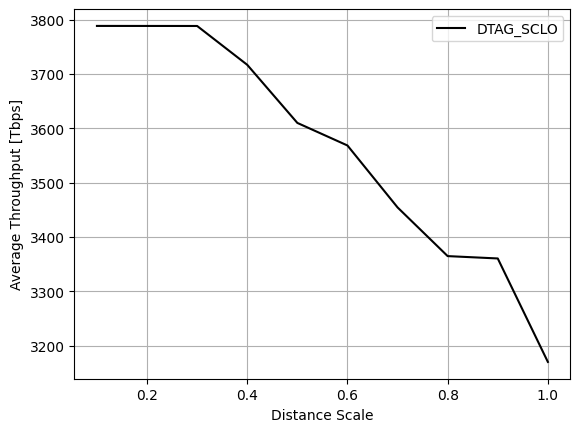

In [91]:
import matplotlib.pyplot as plt
# scaling_df[np.logical_and(scaling_df["name"]=="SBAG",scaling_df["nodes"]==30)].groupby(["scale"])["ilp_throughput"].mean().plot(label="SNR-BA", linestyle="dashed", c="blue")
# scaling_df[np.logical_and(scaling_df["name"]=="BA",scaling_df["nodes"]==30)].groupby(["scale"])["ilp_throughput"].mean().plot(label="BA", linestyle="dotted", c="blue")
# scaling_df[np.logical_and(scaling_df["name"]=="ER",scaling_df["nodes"]==30)].groupby(["scale"])["ilp_throughput"].mean().plot(label="ER", linestyle="dotted", c="red")

plt.style.use('default')
# 动态从数据中读取节点数，而不是硬编码
# 从 scaling_df 中获取该 topology 的节点数（取最常见的节点数，因为可能有多个实例）
topology_data = scaling_df[scaling_df["name"]==dic]
if len(topology_data) > 0:
    nodes_count = topology_data["nodes"].mode()[0] if len(topology_data["nodes"].mode()) > 0 else topology_data["nodes"].iloc[0]
    print(f"Detected nodes_count for {dic}: {nodes_count}")
else:
    raise ValueError(f"No data found for topology '{dic}' in scaling_df")
scaling_df[np.logical_and(scaling_df["name"]==dic,scaling_df["nodes"]==nodes_count)].groupby(["scale"])["ilp_throughput"].mean().plot(label=f"{dic}_{band}", c="black")
plt.grid()
plt.legend()
plt.xlabel("Distance Scale")
plt.ylabel("Average Throughput [Tbps]")
# tikzplotlib.save("CONUS_scaling.tex")
# scaling_df[scaling_df["name"]=="SBAG"].groupby(["scale"])["ilp_throughput"].mean().plot(label="SNR-BA")
plt.savefig(f"{dic}_scaling_{band}.png", dpi=300, bbox_inches='tight')


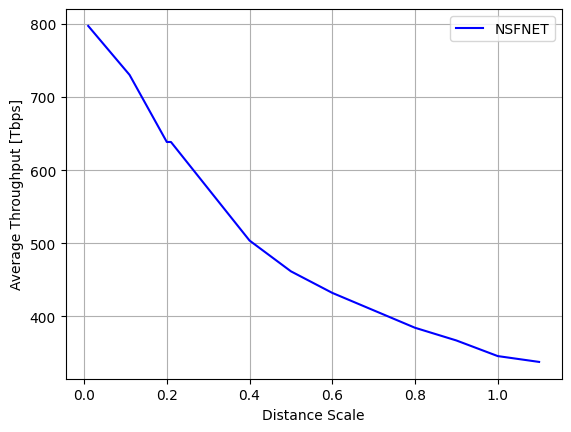

In [ ]:
# scaling_df[np.logical_and(scaling_df["name"]=="SBAG",scaling_df["nodes"]==14)].groupby(["scale"])["ilp_throughput"].mean().plot(label="SNR-BA", c="blue", linestyle="dashed")
# scaling_df[np.logical_and(scaling_df["name"]=="BA",scaling_df["nodes"]==14)].groupby(["scale"])["ilp_throughput"].mean().plot(label="BA", linestyle="dotted", c="blue")
# scaling_df[np.logical_and(scaling_df["name"]=="ER",scaling_df["nodes"]==14)].groupby(["scale"])["ilp_throughput"].mean().plot(label="ER", linestyle="dotted", c="red")
plt.style.use('default')
# 动态从数据中读取节点数，而不是硬编码
topology_data = scaling_df[scaling_df["name"]==dic]
if len(topology_data) > 0:
    nodes_count = topology_data["nodes"].mode()[0] if len(topology_data["nodes"].mode()) > 0 else topology_data["nodes"].iloc[0]
    print(f"Detected nodes_count for {dic}: {nodes_count}")
else:
    raise ValueError(f"No data found for topology '{dic}' in scaling_df")
scaling_df[np.logical_and(scaling_df["name"]==dic,scaling_df["nodes"]==nodes_count)].groupby(["scale"])["ilp_throughput"].mean().plot(label=f"{dic}_{band}", c="blue")
plt.grid()
plt.legend()
plt.xlabel("Distance Scale")
plt.ylabel("Average Throughput [Tbps]")
plt.savefig(f"{dic}_scaling_{band}.png", dpi=300, bbox_inches='tight')
# tikzplotlib.save("NSFNET_scaling.tex")

In [59]:
import NetworkToolkit as nt

dic = "DTAP"
band = "C"
collection_name = f"topology_{dic}_distance_scaling_{band}"

# 检查 collection 中是否有数据
results = list(nt.Database.read_data(
    "Topology_Data",
    collection_name,
    find_dic={},
    max_count=10
))

print(f"Collection: {collection_name}")
print(f"Number of documents: {len(results)}")

if len(results) > 0:
    print(f"\nFirst document keys: {list(results[0].keys())}")
    print(f"\nSample data:")
    for key in ["name", "nodes", "edges", "scale", "ilp_throughput"]:
        if key in results[0]:
            print(f"  {key}: {results[0][key]}")
        else:
            print(f"  {key}: NOT FOUND")
else:
    print("No documents found in collection!")
    print("\nChecking if collection exists...")
    # 列出所有 collections
    from pymongo import MongoClient
    # 需要根据你的 MongoDB 配置调整连接
    # client = MongoClient("mongodb://localhost:27017")
    # db = client["Topology_Data"]
    # collections = db.list_collection_names()
    # print(f"Available collections: {[c for c in collections if 'scaling' in c]}")

Collection: topology_DTAG_distance_scaling_C
Number of documents: 10

First document keys: ['_id', 'connectivity', 'topology vector', 'D FF_kSP', 'D ILP', 'D upper bound', 'D lower bound', 'algebraic connectivity', 'cheeger constant', 'total network capacity ILP', 'total network capacity FF_kSP', 'chromatic number', 'RWA density ILP', 'RWA density FF_kSP', 'h', 'topology data', 'RWA config', 'capacity', 'capacity lower', 'capacity upper', 'capacity FF_kSP', 'nodes', 'edges', 'author', 'mean k', 'erratum timestamp', 'T_c', 'original ILP capacity RWA', 'scale', 'name', 'ilp_throughput', 'band', 'topology_name']

Sample data:
  name: DTAG
  nodes: 14
  edges: 23
  scale: 0.1
  ilp_throughput: 545182692883715.3


10it [00:00, 170.50it/s]


Loaded 10 records for DTAG C band


10it [00:00, 170.77it/s]


Loaded 10 records for DTAG CL band


10it [00:00, 158.66it/s]


Loaded 10 records for DTAG SCL band


10it [00:00, 137.37it/s]


Loaded 10 records for DTAG SCLO band
Detected nodes_count for DTAG: 14
Plotted 10 data points for DTAG_C
Plotted 10 data points for DTAG_CL
Plotted 10 data points for DTAG_SCL
Plotted 10 data points for DTAG_SCLO

Figure saved: DTAG_scaling_multiband.png


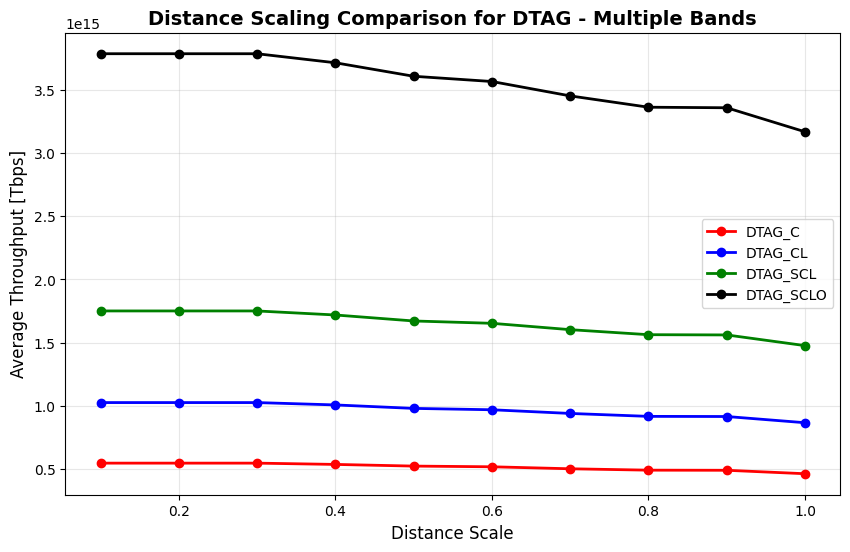

In [93]:
import NetworkToolkit as nt
import numpy as np
import matplotlib.pyplot as plt

# 配置
dic = "DTAG"  # Topology 名称
bands = ["C", "CL", "SCL", "SCLO"]  # 要绘制的频段
colors = {"C": "red", "CL": "blue", "SCL": "green", "SCLO": "black"}  # 每个频段的颜色

# 读取数据
scaling_dfs = {}
for band in bands:
    collection_name = f"topology_{dic}_distance_scaling_{band}"
    try:
        scaling_df = nt.Database.read_topology_dataset_list(
            "Topology_Data",
            collection_name,
            "name",
            "nodes",
            "edges",
            "scale",
            "ilp_throughput",
            find_dic={"name": dic, "nodes": {"$gte": 1}},
            df=True
        )
        if len(scaling_df) > 0:
            scaling_dfs[band] = scaling_df
            print(f"Loaded {len(scaling_df)} records for {dic} {band} band")
        else:
            print(f"WARNING: No data found for {dic} {band} band in collection {collection_name}")
    except Exception as e:
        print(f"ERROR loading {dic} {band} band: {e}")
        continue

# 检查是否有数据
if len(scaling_dfs) == 0:
    raise ValueError(f"No scaling data found for topology '{dic}'")

# 动态从数据中读取节点数
# 取第一个有效数据集的节点数（所有频段应该使用相同的 topology，所以节点数应该相同）
first_band = list(scaling_dfs.keys())[0]
topology_data = scaling_dfs[first_band][scaling_dfs[first_band]["name"] == dic]
if len(topology_data) > 0:
    nodes_count = topology_data["nodes"].mode()[0] if len(topology_data["nodes"].mode()) > 0 else topology_data["nodes"].iloc[0]
    print(f"Detected nodes_count for {dic}: {nodes_count}")
else:
    raise ValueError(f"No data found for topology '{dic}' in scaling_df")

# 绘图
plt.style.use('default')
plt.figure(figsize=(10, 6))

for band in bands:
    if band not in scaling_dfs:
        print(f"Skipping {band} band - no data available")
        continue

    scaling_df = scaling_dfs[band]
    color = colors.get(band, "gray")

    # 过滤数据并计算平均值
    filtered_data = scaling_df[
        np.logical_and(
            scaling_df["name"] == dic,
            scaling_df["nodes"] == nodes_count
        )
    ]

    if len(filtered_data) > 0:
        # 按 scale 分组并计算平均 throughput
        grouped = filtered_data.groupby(["scale"])["ilp_throughput"].mean()
        grouped.plot(label=f"{dic}_{band}", c=color, linewidth=2, marker='o', markersize=6)
        print(f"Plotted {len(grouped)} data points for {dic}_{band}")
    else:
        print(f"WARNING: No filtered data for {dic}_{band} with nodes={nodes_count}")

plt.grid(True, alpha=0.3)
plt.legend(loc='best', fontsize=10)
plt.xlabel("Distance Scale", fontsize=12)
plt.ylabel("Average Throughput [Tbps]", fontsize=12)
plt.title(f"Distance Scaling Comparison for {dic} - Multiple Bands", fontsize=14, fontweight='bold')

# 保存图片
output_filename = f"{dic}_scaling_multiband.png"
plt.savefig(output_filename, dpi=300, bbox_inches='tight')
print(f"\nFigure saved: {output_filename}")

plt.show()